# About this Notebook

This is a Python notebook. This is the notebook you'll use to run and create the analysis code on pickle data sets. Pickle files are created and premanufactured from ROOT files from MicroBooNE LAr experiment.

You should have access to: example_neutrino.ipynb, neutrino_function.py, data folder. You are free to modify neutrino_function.py or create your own plotting functions.

**IMPORTANT:** It is strongly recommended that only **one** student of a lab pair should edit this notebook and the files contained within the server directories. This is because both students cannot see the same live edit of the notebook or files at the same time, and it is easy to accidently overwrite each other.

Code that is commented out with two hashtags should be uncommented when in use.

# All imports

The basic libraries, you may import more if there are present on the server's environment. If you dont have these packages installed on your local machine, you can use **pip install X** or **pip3 install X** to start using them.

In [1]:
import numpy as np
#import uproot3
import pickle

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import Neutrino_functions

from math import *
import scipy as sci

# MACHINE LEARNING IMPORTS
import sklearn
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
from numpy.linalg import norm
import numpy as np
import pickle

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import Neutrino_functions

from math import *
import scipy as sci

# MACHINE LEARNING IMPORTS
import sklearn
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


full = False

# Opening the MC and data frames

In [2]:
# MC
MC_file = './data/MC_EXT_flattened.pkl'

# Data
data_file = './data/data_flattened.pkl'


# Open file as pandas dataframe
MC_EXT = pd.read_pickle(MC_file)
print(len(MC_EXT))
data = pd.read_pickle(data_file)

# removing 'Subevent' from data
MC_EXT = MC_EXT.drop('Subevent', axis = 1)
data = data.drop('Subevent', axis = 1)
MC_EXT = MC_EXT[MC_EXT["trk_energy_tot"]< 1000]
data = data[data["trk_energy_tot"]< 1000]

555624


# You can display the dataframe by uncommenting these lines and running the cell

In [3]:
# Uncomment these lines to display the dataframes
pd.set_option('display.max_columns', 100)
# displays top 10 results.
data.head(10)

,_closestNuCosmicDist,trk_len_v,trk_distance_v,category,topological_score,trk_sce_end_z_v,trk_sce_end_y_v,trk_sce_end_x_v,trk_score_v,trk_llr_pid_score_v,trk_sce_start_z_v,trk_sce_start_y_v,trk_sce_start_x_v,reco_nu_vtx_sce_x,reco_nu_vtx_sce_y,reco_nu_vtx_sce_z,trk_energy_tot,trk_range_muon_mom_v,trk_mcs_muon_mom_v
2,177.083498,174.338699,0.057629,0,0.588847,978.765259,9.115969,153.437668,0.999995,0.970214,852.828674,-36.029785,42.856102,42.869896,-35.978130,852.848938,0.629191,0.502137,0.551996
4,36.361293,493.096283,0.465464,0,0.983048,865.795166,-56.678547,80.313004,1.0,0.990403,408.639801,96.316406,141.032898,141.039246,96.385994,408.178772,1.296849,1.220361,1.124005
9,162.177990,47.523987,0.030297,0,0.336266,892.599304,-59.251465,37.77512,0.93185,0.761358,870.96521,-33.337875,71.00219,71.004707,-33.363049,870.948181,0.286233,0.220104,0.228
18,252.584479,41.466377,245.665344,0,0.085604,793.749878,-28.021137,212.76796,0.94698,-0.850419,760.299255,-16.631842,227.734436,48.110115,87.131821,629.476379,0.793034,0.205175,0.124
19,252.584479,27.905106,0.184222,0,0.085604,629.119751,61.044838,38.428596,0.871483,0.705228,629.406067,87.057205,48.259758,48.110115,87.131821,629.476379,0.793034,0.169452,0.18
25,78.172606,135.382645,0.285119,0,0.075978,216.147156,60.092606,66.720665,0.999741,0.937938,191.35379,-68.321014,33.842884,33.790279,-68.503273,191.568085,0.675723,0.41742,0.359999
26,78.172606,36.155666,4.740094,0,0.075978,185.708649,-101.658852,36.681435,0.915089,0.749608,187.412918,-66.204346,33.827469,33.790279,-68.503273,191.568085,0.675723,0.191648,0.135
34,0.118787,168.128113,0.118787,0,0.048484,230.896637,-31.807461,69.144348,0.999979,0.932326,225.434174,50.903389,214.823349,214.914810,50.938358,225.506363,0.577226,0.488616,0.446998
39,200.240064,141.441833,0.728723,0,0.769795,23.525881,-15.521919,6.777124,0.999706,0.819561,59.999039,8.299944,140.955826,141.630051,8.193906,60.148083,0.625486,0.430597,0.447998
40,200.240064,6.449646,4.252118,0,0.769795,67.308113,11.05552,147.973282,0.793538,0.248862,63.326035,7.909087,144.281403,141.630051,8.193906,60.148083,0.625486,0.094696,0.121


In [4]:
MC_EXT.head(10)

,_closestNuCosmicDist,trk_len_v,trk_distance_v,category,topological_score,trk_sce_end_z_v,trk_sce_end_y_v,trk_sce_end_x_v,trk_score_v,trk_llr_pid_score_v,trk_sce_start_z_v,trk_sce_start_y_v,trk_sce_start_x_v,reco_nu_vtx_sce_x,reco_nu_vtx_sce_y,reco_nu_vtx_sce_z,trk_energy_tot,trk_range_muon_mom_v,trk_mcs_muon_mom_v,weight,true_E,true_L,true_muon_mom
0,124.478148,225.284348,1.286398,21,0.994485,510.146088,-19.997118,191.864334,1.0,0.977081,343.433655,35.865448,54.776821,53.900658,36.203041,342.578735,1.164239,0.613618,0.624997,0.000002,1.371928,438.602722,0.607686
1,124.478148,7.850903,131.947891,21,0.994485,389.239197,46.669083,183.160797,0.041434,0.486446,382.998871,47.109879,178.486572,53.900658,36.203041,342.578735,1.164239,0.101568,0.093,0.000002,1.371928,438.602722,0.607686
13,0.278488,75.551727,0.208943,21,0.984373,559.447205,-81.352386,93.415474,0.902821,0.897909,552.531433,-101.085739,165.269608,165.071518,-101.099983,552.576782,0.888904,0.2855,0.259,0.158957,0.947602,422.767517,0.283484
14,0.278488,27.239777,386.296997,21,0.984373,202.525604,113.942856,176.226593,0.979166,0.486213,212.248871,92.057907,188.679962,165.071518,-101.099983,552.576782,0.888904,0.167584,0.13,0.158957,0.947602,422.767517,0.283484
18,102.236239,336.885345,0.551396,21,0.303120,928.724365,-90.971352,79.272659,1.0,0.986322,635.740723,71.252426,92.555511,92.325119,71.708237,635.880127,0.868494,0.862124,0.816997,0.186696,0.993030,452.664978,0.890139
19,0.398503,245.962036,0.428335,4,0.117459,363.98056,79.766335,32.257286,1.0,0.969633,265.685577,-59.910896,204.181488,204.091019,-60.350964,265.883209,0.697815,0.659197,0.605998,0.183122,1.087948,457.367279,0.915925
20,95.951928,207.38681,2.622469,21,0.035761,690.914062,-99.93821,62.717648,1.0,0.976205,585.692139,74.237633,94.77076,94.815567,72.428185,583.826355,0.763132,0.574328,0.529997,0.179834,0.986055,433.345581,0.573724
21,95.951928,8.074625,1.437311,21,0.035761,588.99939,78.12323,93.21698,0.295619,0.101146,582.77533,73.385559,95.031204,94.815567,72.428185,583.826355,0.763132,0.102612,0.103,0.179834,0.986055,433.345581,0.573724
25,116.876312,63.389645,0.633116,21,0.884215,465.989136,-58.62722,82.079384,0.974152,0.926682,410.665558,-87.696518,73.786499,73.916153,-88.119781,410.201050,0.674289,0.257676,0.229,0.158957,0.741877,467.205078,0.263914
26,119.110161,172.331528,1.101553,21,0.229745,700.726685,-5.288475,16.133368,0.999529,0.97562,545.284302,67.96907,9.661806,9.540943,68.529922,546.222839,0.508720,0.497766,0.531997,0.248403,0.957167,422.609741,0.527036


# Machine learning for Particle Classification

First, look at a sub-sample of our Monte Carlo data.

In [5]:
# Reduce the amount of data for visualisation purposes
MC_EXT_VIS = MC_EXT.sample(int(len(MC_EXT)/10), random_state=1)

# Resetting the index
MC_EXT_VIS.reset_index(drop=True, inplace=True)

# Removing high energy (unphysical) monte carlo results
MC_EXL_VIS = MC_EXT_VIS.drop(MC_EXT_VIS[MC_EXT_VIS.trk_energy_tot > 2].index, inplace = True)

# Resetting the index again
MC_EXT_VIS.reset_index(drop=True, inplace=True)

# Displaying dataframe
print("Length of new data sample: {}".format(len(MC_EXT_VIS)))
MC_EXT_VIS.head(10)


Length of new data sample: 14436


,_closestNuCosmicDist,trk_len_v,trk_distance_v,category,topological_score,trk_sce_end_z_v,trk_sce_end_y_v,trk_sce_end_x_v,trk_score_v,trk_llr_pid_score_v,trk_sce_start_z_v,trk_sce_start_y_v,trk_sce_start_x_v,reco_nu_vtx_sce_x,reco_nu_vtx_sce_y,reco_nu_vtx_sce_z,trk_energy_tot,trk_range_muon_mom_v,trk_mcs_muon_mom_v,weight,true_E,true_L,true_muon_mom
0,121.328035,351.759583,1.054885,21,0.903750,719.911743,81.834724,228.551208,1.0,0.986384,397.060638,100.335175,96.641907,96.367538,100.456635,396.050781,1.101487,0.895713,0.912997,0.174654,1.154694,453.000488,0.923473
1,112.351548,68.981178,0.156776,21,0.332733,525.466248,-39.567028,176.920593,0.974764,0.251436,585.257629,-49.112251,204.485794,204.527283,-48.953148,585.308228,0.290209,0.270548,0.21,0.493972,0.528848,456.763611,0.170075
2,242.136577,92.237366,0.056001,21,0.386409,391.505005,-55.013977,45.417229,0.99524,0.944101,308.54071,-43.608749,8.734032,8.789061,-43.619072,308.538940,0.339523,0.322879,0.320999,0.201212,0.737712,444.423706,0.328997
3,77.962206,135.689972,1.162818,21,0.938583,391.862213,60.89529,130.591675,0.999971,0.963881,288.231781,31.539289,48.608318,47.933681,31.327419,287.349457,1.138630,0.418088,0.467997,0.204502,0.540315,462.099518,0.412406
4,351.929715,67.826614,0.528558,21,0.488964,648.401184,88.088058,50.160465,0.987937,0.900802,612.913513,36.316528,75.348106,75.433472,36.783047,612.683838,0.782261,0.267902,0.301,0.158957,1.310193,434.788818,0.276793
5,16.889163,65.432327,0.719802,21,0.993054,315.448578,0.151142,177.893112,0.982767,0.852404,357.631989,-3.685479,128.529465,129.061493,-3.624397,357.156921,0.669301,0.262397,0.248,0.158957,0.779725,464.367584,0.268438
6,126.252572,161.802505,0.110369,7,0.042078,828.604187,107.225121,94.2173,1.0,0.965029,813.889709,-46.272324,138.930084,138.958862,-46.368050,813.949585,0.486327,0.474856,0.565996,0.257732,1.000000,0.000000,0.000000
7,159.629866,113.537933,0.392584,7,0.052385,383.288666,-97.316788,122.157623,0.973345,0.923716,356.007355,-24.676113,39.899879,40.111671,-24.975716,356.145569,0.384404,0.369785,0.347999,0.257732,1.000000,0.000000,0.000000
8,121.748246,236.374512,0.465702,21,0.906986,376.382874,-50.0467,43.11092,1.0,0.973608,188.019882,84.461975,28.626125,28.556261,84.592293,187.577072,1.032695,0.638038,0.581998,0.158957,1.370541,442.339569,0.635827
9,76.720335,61.386917,0.200674,21,0.954028,598.213196,-13.662055,106.526268,0.988295,-0.889968,538.860657,-29.046234,106.24292,106.233673,-29.000799,538.664612,0.531948,0.253027,0.309999,0.204741,0.579981,442.082489,0.167705


In [6]:
import numpy as np

class Neural_Network(object):
    def __init__(self, input_size=2, hidden_sizes=(4,), output_size=1, seed=None, Lambda=0,
                 pos_weight=1.0, neg_weight=1.0, activation="leakyrelu", alpha=0.01):
        """
        input_size: number of input features
        hidden_sizes: list/tuple defining hidden layer widths
        output_size: output dimension (1 for binary classification)
        Lambda: L2 regularisation coefficient
        pos_weight / neg_weight: class weights for imbalance
        activation: one of ['sigmoid', 'relu', 'leakyrelu', 'tanh']
        alpha: slope for leaky ReLU
        """
        if seed is not None:
            np.random.seed(seed)
        self.Lambda = Lambda
        self.pos_weight = float(pos_weight)
        self.neg_weight = float(neg_weight)
        self.activation = activation.lower()
        self.alpha = alpha

        self.layer_sizes = [input_size] + list(hidden_sizes) + [output_size]
        self.weights = [
            np.random.randn(self.layer_sizes[i], self.layer_sizes[i + 1])
            for i in range(len(self.layer_sizes) - 1)
        ]

    # --------- Activation functions ---------
    @staticmethod
    def sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def sigmoidPrime(z):
        s = 1.0 / (1.0 + np.exp(-z))
        return s * (1.0 - s)

    def act(self, z):
        if self.activation == "sigmoid":
            return self.sigmoid(z)
        elif self.activation == "tanh":
            return np.tanh(z)
        elif self.activation == "relu":
            return np.maximum(0, z)
        elif self.activation == "leakyrelu":
            return np.where(z > 0, z, self.alpha * z)
        else:
            raise ValueError(f"Unknown activation '{self.activation}'")

    def actPrime(self, z):
        if self.activation == "sigmoid":
            return self.sigmoidPrime(z)
        elif self.activation == "tanh":
            return 1.0 - np.tanh(z) ** 2
        elif self.activation == "relu":
            return (z > 0).astype(float)
        elif self.activation == "leakyrelu":
            return np.where(z > 0, 1.0, self.alpha)
        else:
            raise ValueError(f"Unknown activation '{self.activation}'")

    # --------- Forward pass ---------
    def forward(self, X):
        activations = [X]
        zs = []
        for i, W in enumerate(self.weights):
            z = activations[-1] @ W
            # Apply activation except final layer (sigmoid output)
            if i < len(self.weights) - 1:
                a = self.act(z)
            else:
                a = self.sigmoid(z)
            zs.append(z)
            activations.append(a)
        self._cache = {"activations": activations, "zs": zs}
        return activations[-1]

    # --------- Loss (Weighted BCE + L2) ---------
    def costFunction(self, X, y):
        lam = getattr(self, "Lambda", 0.0)
        w_pos = getattr(self, "pos_weight", 1.0)
        w_neg = getattr(self, "neg_weight", 1.0)

        yHat = self.forward(X)
        yHat = np.clip(yHat, 1e-10, 1.0 - 1e-10)
        m = X.shape[0]

        data_term = -np.mean(w_pos * y * np.log(yHat) + w_neg * (1 - y) * np.log(1 - yHat))
        reg_term = 0.5 * lam * sum(np.sum(W ** 2) for W in self.weights)
        return data_term + reg_term

    # --------- Backpropagation ---------
    def costFunctionPrime(self, X, y):
        lam = getattr(self, "Lambda", 0.0)
        w_pos = getattr(self, "pos_weight", 1.0)
        w_neg = getattr(self, "neg_weight", 1.0)

        yHat = self.forward(X)
        activations = self._cache["activations"]
        zs = self._cache["zs"]
        m = X.shape[0]

        grads = [None] * len(self.weights)

        aL = activations[-1]
        # Output layer delta
        delta = w_neg * (1 - y) * aL - w_pos * y * (1 - aL)
        grads[-1] = (activations[-2].T @ delta) / m + lam * self.weights[-1]

        # Hidden layers
        for l in range(len(self.weights) - 2, -1, -1):
            delta = (delta @ self.weights[l + 1].T) * self.actPrime(zs[l])
            grads[l] = (activations[l].T @ delta) / m + lam * self.weights[l]

        return grads

    # --------- Parameter utilities ---------
    def getParams(self):
        return np.concatenate([W.ravel() for W in self.weights])

    def setParams(self, params):
        new_weights = []
        idx = 0
        for i in range(len(self.layer_sizes) - 1):
            rows = self.layer_sizes[i]
            cols = self.layer_sizes[i + 1]
            size = rows * cols
            W = params[idx: idx + size].reshape(rows, cols)
            new_weights.append(W)
            idx += size
        self.weights = new_weights

    def computeGradients(self, X, y):
        grads = self.costFunctionPrime(X, y)
        return np.concatenate([g.ravel() for g in grads])


In [7]:
from scipy import optimize
import numpy as np

class trainer(object):
    def __init__(self, N):
        # Make Local reference to network:
        self.N = N

    # ---------- BFGS plumbing (unchanged) ----------
    def callbackF(self, params):
        self.N.setParams(params)
        self.J.append(self.N.costFunction(self.X, self.y))
        self.testJ.append(self.N.costFunction(self.testX, self.testY))

    def costFunctionWrapper(self, params, X, y):
        self.N.setParams(params)
        cost = self.N.costFunction(X, y)
        grad = self.N.computeGradients(X, y)
        return cost, grad

    # ---------- Public train entry ----------
    def train(self, trainX, trainY, testX, testY,
              optimizer='bfgs',
              maxiter=200,
              # Adam hyperparams (ignored for BFGS)
              epochs=50, batch_size=256, lr=1e-2,
              beta1=0.9, beta2=0.999, eps=1e-8,
              patience=None):
        """
        optimizer: 'bfgs' (default) or 'adam'
        If optimizer='bfgs', only maxiter is used (matches your original).
        If optimizer='adam', uses epochs/batch_size/lr/betas/eps; optional early stopping via patience (in epochs).
        """
        # Store for callbacks/metrics
        self.X, self.y = trainX, trainY
        self.testX, self.testY = testX, testY
        self.J, self.testJ = [], []

        if optimizer.lower() == 'bfgs':
            # ---- Original BFGS path (unchanged) ----
            params0 = self.N.getParams()
            options = {'maxiter': maxiter, 'disp': True}
            _res = optimize.minimize(self.costFunctionWrapper, params0, jac=True, method='BFGS',
                                     args=(trainX, trainY), options=options, callback=self.callbackF)
            self.N.setParams(_res.x)
            self.optimizationResults = _res
            return

        # ---------- Adam mini-batch optimizer ----------
        params = self.N.getParams()
        m = np.zeros_like(params)
        v = np.zeros_like(params)
        t = 0

        n = trainX.shape[0]
        if isinstance(batch_size, (float, int)) is False or batch_size is None:
            batch_size = 256
        batch_size = max(1, min(int(batch_size), n))

        best_test = np.inf
        best_params = params.copy()
        bad_epochs = 0

        for epoch in range(1, epochs + 1):
            # Shuffle indices
            idx = np.random.permutation(n)
            # Mini-batches
            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                b = idx[start:end]
                Xb = trainX[b]
                yb = trainY[b]

                # Gradient for current params on batch
                self.N.setParams(params)
                g = self.N.computeGradients(Xb, yb)

                # Adam updates
                t += 1
                m = beta1 * m + (1 - beta1) * g
                v = beta2 * v + (1 - beta2) * (g * g)
                m_hat = m / (1 - beta1 ** t)
                v_hat = v / (1 - beta2 ** t)

                params = params - lr * m_hat / (np.sqrt(v_hat) + eps)

            # Set updated params after epoch
            self.N.setParams(params)

            # Track full-batch train/test cost each epoch
            train_cost = self.N.costFunction(trainX, trainY)
            test_cost  = self.N.costFunction(testX,  testY)
            self.J.append(train_cost)
            self.testJ.append(test_cost)

            # Early stopping (optional)
            if patience is not None:
                if test_cost < best_test - 1e-7:
                    best_test = test_cost
                    best_params = params.copy()
                    bad_epochs = 0
                else:
                    bad_epochs += 1
                    if bad_epochs >= patience:
                        # Restore best
                        self.N.setParams(best_params)
                        break

        # Save final params for consistency with BFGS path
        self.optimizationResults = {
            'optimizer': 'adam',
            'epochs_done': len(self.J),
            'final_train_cost': self.J[-1] if self.J else None,
            'final_test_cost': self.testJ[-1] if self.testJ else None
        }


In [8]:
def computeNumericalGradient(N, X, y):
        paramsInitial = N.getParams()
        numgrad = np.zeros(paramsInitial.shape)
        perturb = np.zeros(paramsInitial.shape)
        e = 1e-4

        for p in range(len(paramsInitial)):
            #Set perturbation vector
            perturb[p] = e
            N.setParams(paramsInitial + perturb)
            loss2 = N.costFunction(X, y)
            
            N.setParams(paramsInitial - perturb)
            loss1 = N.costFunction(X, y)

            #Compute Numerical Gradient
            numgrad[p] = (loss2 - loss1) / (2*e)

            #Return the value we changed to zero:
            perturb[p] = 0
            
        #Return Params to original value:
        N.setParams(paramsInitial)

        return numgrad 

In [9]:
# MC
MC_file = './data/MC_EXT_flattened.pkl'

# Data
data_file = './data/data_flattened.pkl'


# Open file as pandas dataframe
MC_EXT = pd.read_pickle(MC_file)
data = pd.read_pickle(data_file)

# removing 'Subevent' from data
MC_EXT = MC_EXT.drop('Subevent', axis = 1)
data = data.drop('Subevent', axis = 1)
MC_EXT = MC_EXT[MC_EXT["trk_energy_tot"]< 2]
data = data[data["trk_energy_tot"]< 2]

features = ['_closestNuCosmicDist', 'trk_len_v', 'trk_distance_v', 'topological_score', 'trk_sce_end_z_v', 'trk_sce_end_y_v', 'trk_sce_end_x_v', 'trk_score_v', 'trk_llr_pid_score_v', 'trk_sce_start_z_v', 'trk_sce_start_y_v', 'trk_sce_start_x_v', 'reco_nu_vtx_sce_x', 'reco_nu_vtx_sce_y', 'reco_nu_vtx_sce_z', 'trk_energy_tot']
output = ['category']

X = MC_EXT[features]
y = np.array(MC_EXT['category']==21)


In [10]:
trainX, testX, trainY, testY = train_test_split(X, y, test_size=0.2, random_state=1)

#Normalize:
trainX = trainX/np.amax(trainX, axis=0)


#Normalize by max of training data:
testX = testX/np.amax(trainX, axis=0)

#trainX = np.array(trainX, dtype=float)
#testX = np.array(testX, dtype=float)
#trainY = np.array(trainY, dtype=float).reshape(-1, 1)
#testY = np.array(testY, dtype=float).reshape(-1, 1)

trainX = np.asarray(trainX, dtype=float)
trainY = np.asarray(trainY, dtype=float).reshape(-1, 1)
testX = np.asarray(testX, dtype=float)
testY = np.asarray(testY, dtype=float).reshape(-1, 1)


ARCH = (8, 8)
LAMBDA = 1e-5
POS_W, NEG_W = 1.0, 3.0
LR = 5e-3
EPOCHS = 150
alpha = 0.1
NN = Neural_Network(
        input_size=trainX.shape[1],
        hidden_sizes=ARCH,
        Lambda=LAMBDA,
        pos_weight=POS_W,
        neg_weight=NEG_W,
        activation="leakyrelu",
        alpha=alpha
    )
T = trainer(NN)
T.train(trainX, trainY, testX, testY, optimizer='adam', lr=LR, epochs=EPOCHS)

In [11]:
X = np.asarray(X, dtype=np.float64)
y = np.asarray(y, dtype=np.float64)

preds = NN.forward(trainX).ravel()
y_true = trainY.ravel()

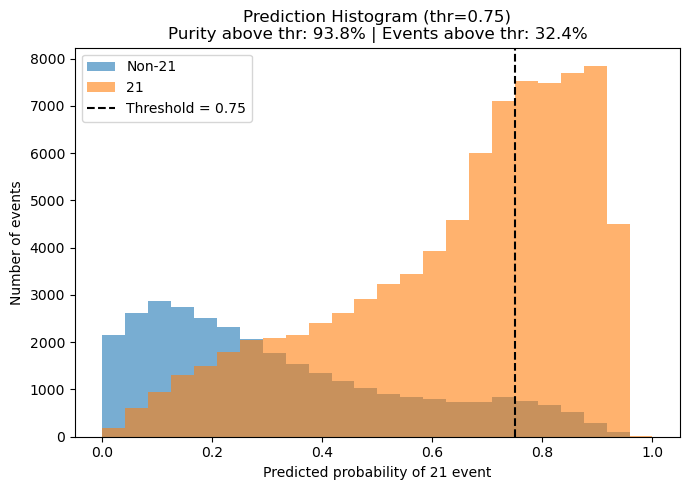

Purity above threshold (0.75): 93.76%
Fraction of all events above threshold: 32.45%


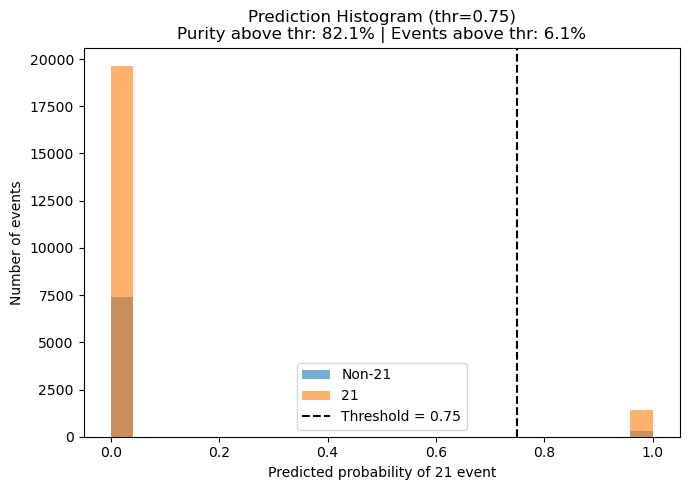

Purity above threshold (0.75): 82.07%
Fraction of all events above threshold: 6.09%


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pred_histogram(preds, y_true, threshold=0.75, bins=25):
    """
    Plot histogram of model predictions, showing separate distributions
    for 21 and non-21 events.

    Parameters
    ----------
    preds : array-like, shape (n_samples,)
        Model output probabilities (0–1).
    y_true : array-like, shape (n_samples,)
        True labels (0 or 1).
    threshold : float
        Classification threshold for marking region above cut.
    bins : int
        Number of histogram bins.
    """
    preds = np.asarray(preds, dtype=float).ravel()
    y_true = np.asarray(y_true, dtype=int).ravel()

    preds_21 = preds[y_true == 1]
    preds_non21 = preds[y_true == 0]

    # Compute purity and fraction above threshold
    above_thr = preds > threshold
    n_above = np.sum(above_thr)
    n_21_above = np.sum((y_true == 1) & above_thr)
    purity = 100 * n_21_above / n_above if n_above > 0 else 0.0
    frac_above = 100 * n_above / len(preds)

    # Plot histograms
    plt.figure(figsize=(7, 5))
    bins = np.linspace(0, 1, bins)
    plt.hist(preds_non21, bins=bins, alpha=0.6, label="Non-21", color="tab:blue")
    plt.hist(preds_21, bins=bins, alpha=0.6, label="21", color="tab:orange")

    # Threshold line
    plt.axvline(threshold, color='k', linestyle='--', linewidth=1.5,
                label=f"Threshold = {threshold}")

    plt.xlabel("Predicted probability of 21 event")
    plt.ylabel("Number of events")
    plt.title(
        f"Prediction Histogram (thr={threshold})\n"
        f"Purity above thr: {purity:.1f}% | "
        f"Events above thr: {frac_above:.1f}%"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Purity above threshold ({threshold}): {purity:.2f}%")
    print(f"Fraction of all events above threshold: {frac_above:.2f}%")

# Example usage:
# preds = NN.forward(testX).ravel()
# y_true = testY.ravel()
plot_pred_histogram(preds, y_true, threshold=0.75)

# Example usage:
preds = NN.forward(testX).ravel()
y_true = testY.ravel()
plot_pred_histogram(preds, y_true, threshold=0.75)


# Exercise 9: Plot the energy spectrums here and normalise

Final representation of MC and data after applying the cuts.

=== Threshold Cut @ 0.75 ===
MC events:   144,211 → 8,924  (6.19% kept)
Data events: 28,808 → 1,848  (6.41% kept)


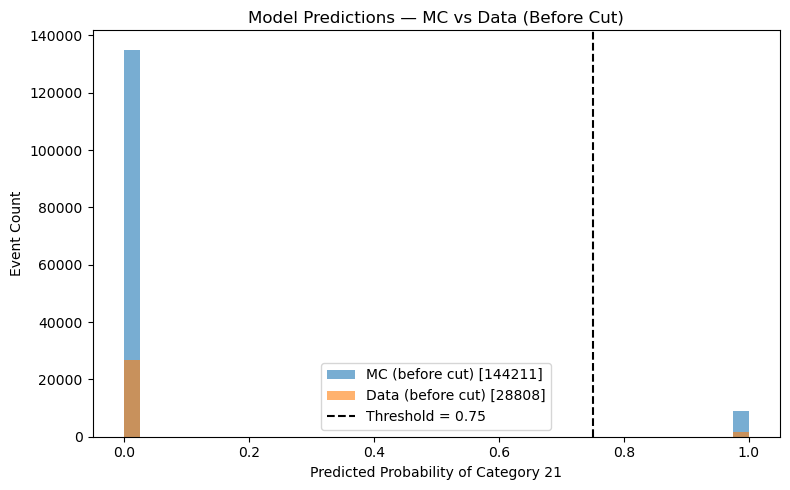

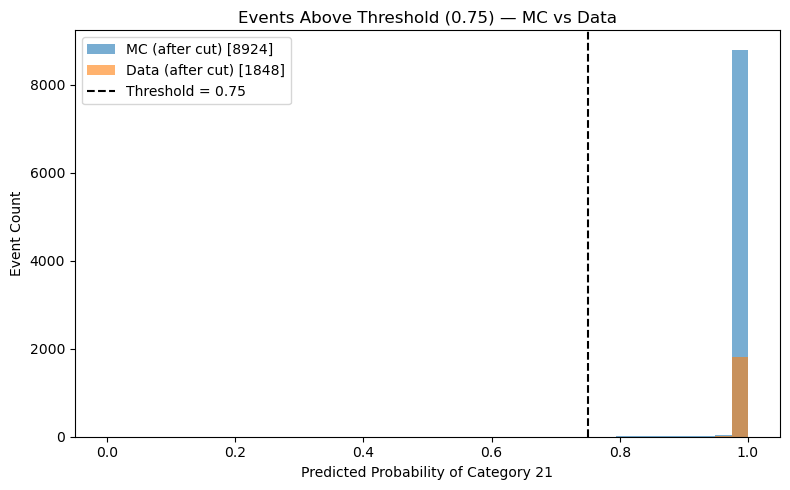

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# CONFIG
# ==========================================================
threshold = 0.75

# ==========================================================
# MODEL PREDICTIONS
# ==========================================================
preds_MC = NN.forward(MC_EXT[features].to_numpy(dtype=float)).ravel()
preds_data = NN.forward(data[features].to_numpy(dtype=float)).ravel()

# ==========================================================
# APPLY THRESHOLD CUT
# ==========================================================
mask_MC = preds_MC > threshold
mask_data = preds_data > threshold

MC_EXT_CUT = MC_EXT.loc[mask_MC].copy()
data_frame_cut = data.loc[mask_data].copy()

# ==========================================================
# SUMMARY STATS
# ==========================================================
n_MC_before, n_MC_after = len(MC_EXT), len(MC_EXT_CUT)
n_data_before, n_data_after = len(data), len(data_frame_cut)

print(f"=== Threshold Cut @ {threshold} ===")
print(f"MC events:   {n_MC_before:,} → {n_MC_after:,}  ({100*n_MC_after/n_MC_before:.2f}% kept)")
print(f"Data events: {n_data_before:,} → {n_data_after:,}  ({100*n_data_after/n_data_before:.2f}% kept)")

# ==========================================================
# HISTOGRAMS
# ==========================================================
bins = np.linspace(0, 1, 40)

# Before cut
plt.figure(figsize=(8, 5))
plt.hist(preds_MC, bins=bins, alpha=0.6, label=f"MC (before cut) [{n_MC_before}]")
plt.hist(preds_data, bins=bins, alpha=0.6, label=f"Data (before cut) [{n_data_before}]")
plt.axvline(threshold, color='k', linestyle='--', label=f"Threshold = {threshold}")
plt.title("Model Predictions — MC vs Data (Before Cut)")
plt.xlabel("Predicted Probability of Category 21")
plt.ylabel("Event Count")
plt.legend()
plt.tight_layout()
plt.show()

# After cut
plt.figure(figsize=(8, 5))
plt.hist(preds_MC[mask_MC], bins=bins, alpha=0.6, label=f"MC (after cut) [{n_MC_after}]")
plt.hist(preds_data[mask_data], bins=bins, alpha=0.6, label=f"Data (after cut) [{n_data_after}]")
plt.axvline(threshold, color='k', linestyle='--', label=f"Threshold = {threshold}")
plt.title(f"Events Above Threshold ({threshold}) — MC vs Data")
plt.xlabel("Predicted Probability of Category 21")
plt.ylabel("Event Count")
plt.legend()
plt.tight_layout()
plt.show()


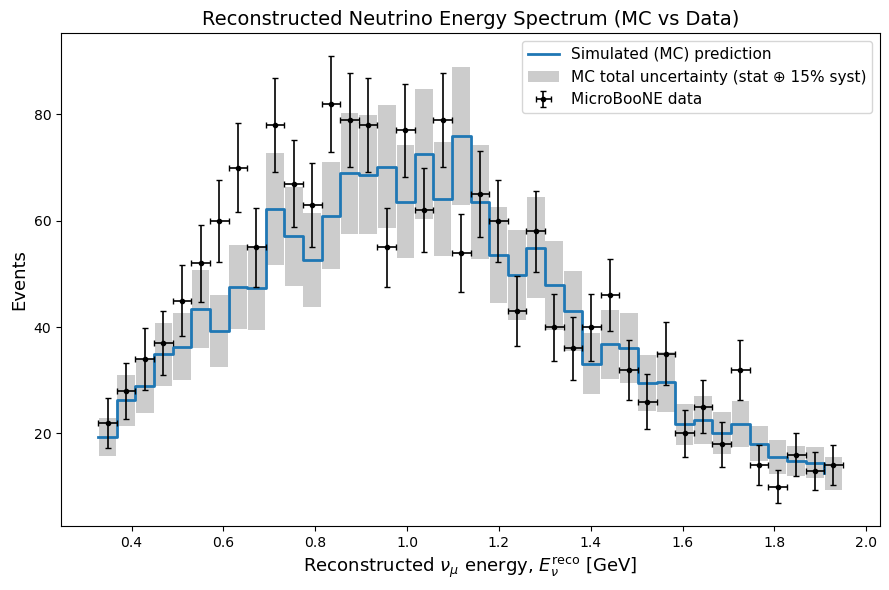

In [14]:
# ===============================
# CONFIGURATION
# ===============================
VAR = "trk_energy_tot"       # Reconstructed neutrino energy
MC_DF = MC_EXT_CUT               # Monte Carlo (predicted) sample
DATA_DF = data_frame_cut               # Real MicroBooNE data
N_BINS = 40                  # Number of histogram bins
SYST_FRAC = 0.15             # 15% systematic uncertainty
LOG_Y = False                # Toggle log scale

# ===============================
# HELPER FUNCTION
# ===============================
def robust_range(series, qlo=0.01, qhi=0.99):
    """Compute robust range ignoring extreme tails."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return None
    lo, hi = np.quantile(s, [qlo, qhi])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = s.min(), s.max()
    return float(lo), float(hi)

# ===============================
# BIN SETUP
# ===============================
rng = robust_range(MC_DF[VAR])
if rng is None:
    raise ValueError(f"No valid numeric data in MC for {VAR}")
lo, hi = rng
bins = np.linspace(lo, hi, N_BINS + 1)
centers = 0.5 * (bins[1:] + bins[:-1])
width = bins[1] - bins[0]

# ===============================
# MONTE CARLO HISTOGRAM
# ===============================
mc_vals = pd.to_numeric(MC_DF[VAR], errors="coerce").dropna()
mc_w = pd.to_numeric(MC_DF.loc[mc_vals.index, "weight"], errors="coerce").fillna(0)

# Weighted histogram
mc_counts, _ = np.histogram(mc_vals, bins=bins, weights=mc_w)

# Statistical uncertainty: Var = sum(w^2)
mc_var_stat, _ = np.histogram(mc_vals, bins=bins, weights=mc_w**2)
mc_sigma_stat = np.sqrt(mc_var_stat)

# Systematic (15% of MC count)
mc_sigma_syst = SYST_FRAC * mc_counts

# Combined uncertainty
mc_sigma_tot = np.sqrt(mc_sigma_stat**2 + mc_sigma_syst**2)

# ===============================
# MICROBOONE DATA HISTOGRAM
# ===============================
data_counts = None
data_sigma = None
if isinstance(DATA_DF, pd.DataFrame) and VAR in DATA_DF.columns:
    data_vals = pd.to_numeric(DATA_DF[VAR], errors="coerce").dropna()
    data_counts, _ = np.histogram(data_vals, bins=bins)
    data_sigma = np.sqrt(data_counts)
else:
    print("[INFO] No valid MicroBooNE data provided; plotting MC only.")

# ===============================
# PLOTTING
# ===============================
plt.figure(figsize=(9, 6))

# Monte Carlo prediction
plt.step(bins[:-1], mc_counts, where="post", color="tab:blue", linewidth=2, label="Simulated (MC) prediction")

# Uncertainty band (statistical + systematic)
plt.bar(
    centers,
    2 * mc_sigma_tot,
    bottom=mc_counts - mc_sigma_tot,
    width=0.95 * width,
    color="gray",
    alpha=0.4,
    label="MC total uncertainty (stat ⊕ 15% syst)"
)

# MicroBooNE data overlay
if data_counts is not None:
    plt.errorbar(
        centers,
        data_counts,
        yerr=data_sigma,
        xerr=width / 2,
        fmt=".k",
        elinewidth=1.2,
        capsize=2,
        label="MicroBooNE data"
    )

plt.xlabel(r"Reconstructed $\nu_\mu$ energy, $E_\nu^{\text{reco}}$ [GeV]", fontsize=13)
plt.ylabel("Events", fontsize=13)
plt.title("Reconstructed Neutrino Energy Spectrum (MC vs Data)", fontsize=14)
plt.legend(fontsize=11)
if LOG_Y:
    plt.yscale("log")
plt.tight_layout()
plt.show()


# Exercise 10: Oscillation and fitting

### a) Define functions requires for Oscillation analysis, test that they work!


In [15]:
# oscillation function
sine = 1
delta = 1
MC_EXT_OSC = MC_EXT_CUT.copy()
def oscillation_prob(sine, delta, length, Energy):
    return 1 - sine*(np.sin(1.27*delta*length/Energy)**2)
MC_EXT_OSC["weight"] = MC_EXT_OSC["weight"]*oscillation_prob(sine, delta, 0.47, MC_EXT_OSC["true_E"])



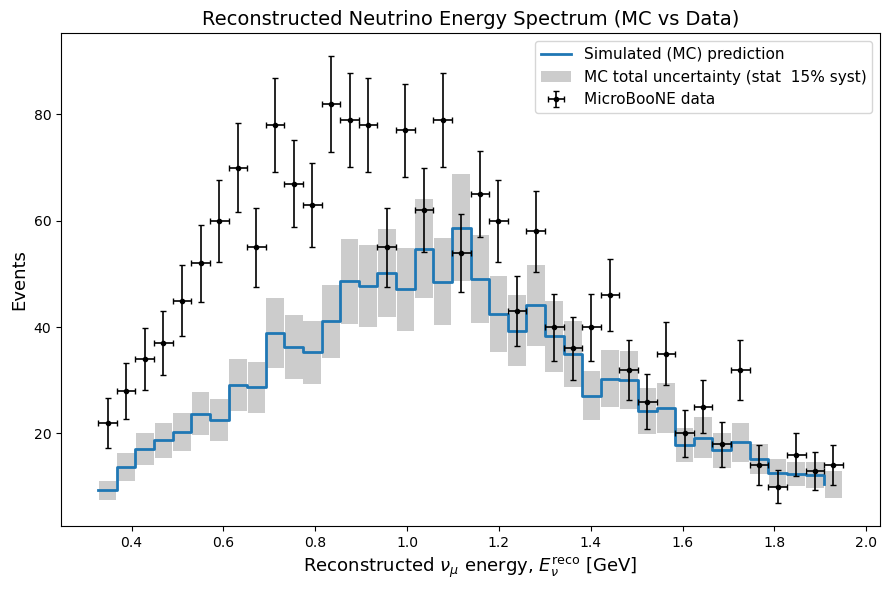

In [16]:

# ===============================
# CONFIGURATION
# ===============================
VAR = "trk_energy_tot"       # Reconstructed neutrino energy
MC_DF = MC_EXT_OSC              # Monte Carlo (predicted) sample
DATA_DF = data_frame_cut               # Real MicroBooNE data
N_BINS = 40                  # Number of histogram bins
SYST_FRAC = 0.15             # 15% systematic uncertainty
LOG_Y = False                # Toggle log scale

# ===============================
# HELPER FUNCTION
# ===============================
def robust_range(series, qlo=0.01, qhi=0.99):
    """Compute robust range ignoring extreme tails."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return None
    lo, hi = np.quantile(s, [qlo, qhi])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = s.min(), s.max()
    return float(lo), float(hi)

# ===============================
# BIN SETUP
# ===============================
rng = robust_range(MC_DF[VAR])
if rng is None:
    raise ValueError(f"No valid numeric data in MC for {VAR}")
lo, hi = rng
bins = np.linspace(lo, hi, N_BINS + 1)
centers = 0.5 * (bins[1:] + bins[:-1])
width = bins[1] - bins[0]

# ===============================
# MONTE CARLO HISTOGRAM
# ===============================
mc_vals = pd.to_numeric(MC_DF[VAR], errors="coerce").dropna()
mc_w = pd.to_numeric(MC_DF.loc[mc_vals.index, "weight"], errors="coerce").fillna(0)

# Weighted histogram
mc_counts, _ = np.histogram(mc_vals, bins=bins, weights=mc_w)

# Statistical uncertainty: Var = sum(w^2)
mc_var_stat, _ = np.histogram(mc_vals, bins=bins, weights=mc_w**2)
mc_sigma_stat = np.sqrt(mc_var_stat)

# Systematic (15% of MC count)
mc_sigma_syst = SYST_FRAC * mc_counts

# Combined uncertainty
mc_sigma_tot = np.sqrt(mc_sigma_stat**2 + mc_sigma_syst**2)

# ===============================
# MICROBOONE DATA HISTOGRAM
# ===============================
data_counts = None
data_sigma = None
if isinstance(DATA_DF, pd.DataFrame) and VAR in DATA_DF.columns:
    data_vals = pd.to_numeric(DATA_DF[VAR], errors="coerce").dropna()
    data_counts, _ = np.histogram(data_vals, bins=bins)
    data_sigma = np.sqrt(data_counts)
else:
    print("[INFO] No valid MicroBooNE data provided; plotting MC only.")

# ===============================
# PLOTTING
# ===============================
plt.figure(figsize=(9, 6))

# Monte Carlo prediction
plt.step(bins[:-1], mc_counts, where="post", color="tab:blue", linewidth=2, label="Simulated (MC) prediction")

# Uncertainty band (statistical + systematic)
plt.bar(
    centers,
    2 * mc_sigma_tot,
    bottom=mc_counts - mc_sigma_tot,
    width=0.95 * width,
    color="gray",
    alpha=0.4,
    label="MC total uncertainty (stat  15% syst)"
)

# MicroBooNE data overlay
if data_counts is not None:
    plt.errorbar(
        centers,
        data_counts,
        yerr=data_sigma,
        xerr=width / 2,
        fmt=".k",
        elinewidth=1.2,
        capsize=2,
        label="MicroBooNE data"
    )

plt.xlabel(r"Reconstructed $\nu_\mu$ energy, $E_\nu^{\text{reco}}$ [GeV]", fontsize=13)
plt.ylabel("Events", fontsize=13)
plt.title("Reconstructed Neutrino Energy Spectrum (MC vs Data)", fontsize=14)
plt.legend(fontsize=11)
if LOG_Y:
    plt.yscale("log")
plt.tight_layout()
plt.show()



In [17]:
# chi squared function


def chi_squared(MC_DF, DATA_DF, variable="trk_energy_tot", n_bins=40, syst_frac=0.15):
    """
    Compute chi-squared statistic between weighted Monte Carlo prediction and real data.

    Parameters
    ----------
    MC_DF : pandas.DataFrame
        Simulated dataset (MC_EXT or equivalent), must include `variable` and `weight`.
    DATA_DF : pandas.DataFrame
        Real MicroBooNE data containing the same `variable`.
    variable : str
        Variable to histogram and compare (default: 'trk_energy_tot').
    n_bins : int
        Number of histogram bins (default: 40).
    syst_frac : float
        Fractional systematic uncertainty (default: 0.15 = 15%).

    Returns
    -------
    chi2 : float
        The χ² value for the data vs. MC comparison.
    ndof : int
        The number of degrees of freedom (N_bins - 1 if all bins used).
    """
    # Check variable presence
    if variable not in MC_DF.columns or variable not in DATA_DF.columns:
        raise ValueError(f"Variable '{variable}' must exist in both dataframes.")

    # Binning range from MC (robust quantiles)
    s = pd.to_numeric(MC_DF[variable], errors="coerce").dropna()
    if s.empty:
        raise ValueError(f"No valid numeric MC data in {variable}.")
    lo, hi = np.quantile(s, [0.01, 0.99])
    bins = np.linspace(lo, hi, n_bins + 1)

    # Weighted MC histogram
    mc_vals = pd.to_numeric(MC_DF[variable], errors="coerce").dropna()
    mc_w = pd.to_numeric(MC_DF.loc[mc_vals.index, "weight"], errors="coerce").fillna(0)
    mc_counts, _ = np.histogram(mc_vals, bins=bins, weights=mc_w)

    # Statistical variance = sum(w^2)
    mc_var_stat, _ = np.histogram(mc_vals, bins=bins, weights=mc_w**2)
    mc_sigma_stat = np.sqrt(mc_var_stat)

    # Systematic uncertainty (fraction of count)
    mc_sigma_syst = syst_frac * mc_counts

    # Combined total uncertainty
    mc_sigma_tot = np.sqrt(mc_sigma_stat**2 + mc_sigma_syst**2)

    # Data histogram (no weights)
    data_vals = pd.to_numeric(DATA_DF[variable], errors="coerce").dropna()
    data_counts, _ = np.histogram(data_vals, bins=bins)
    data_sigma_stat = np.sqrt(data_counts)

    # Total uncertainty per bin: combine data and MC (optional)
    # Here we assume MC dominates uncertainty → use MC σ_i
    sigma_i = mc_sigma_tot.copy()
    sigma_i[sigma_i == 0] = np.inf  # avoid division by zero

    # Compute chi-squared sum
    chi2_terms = (mc_counts - data_counts)**2 / (sigma_i**2)
    chi2 = np.nansum(chi2_terms)
    ndof = np.count_nonzero(np.isfinite(chi2_terms)) - 1

    print(f"χ² = {chi2:.2f} for {ndof} degrees of freedom")
    print(f"Reduced χ² = {chi2/ndof:.2f}")

    return chi2, ndof
chi_squared(MC_DF, DATA_DF)

χ² = 667.59 for 39 degrees of freedom
Reduced χ² = 17.12


(np.float64(667.588907033997), np.int64(39))

# Exercise 11/12: Oscillation parameter scan, contour plotting, closure test.

### Closure test, create your oscillation parameter scanning code, and find minimum values for chi squared!

len(Data_OSC) = 8924
len(MC_EXT_OSC) = 8924


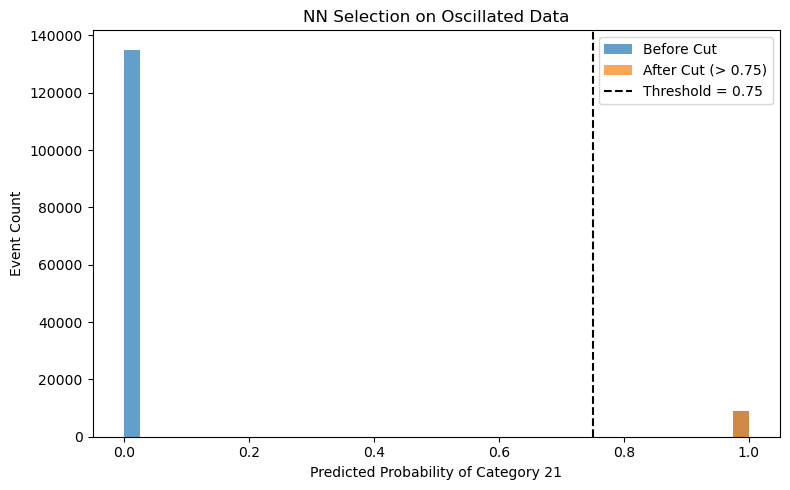

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# CONFIG
# ==========================================================
OSC_file = './data/oscillated_data.pkl'
threshold = 0.75

# ==========================================================
# LOAD OSCILLATED DATA
# ==========================================================
Data_OSC = pd.read_pickle(OSC_file)

# Optional cleanup to match MC/data preprocessing
if 'Subevent' in Data_OSC.columns:
    Data_OSC = Data_OSC.drop('Subevent', axis=1)
if 'trk_energy_tot' in Data_OSC.columns:
    Data_OSC = Data_OSC[Data_OSC['trk_energy_tot'] < 2]

# ==========================================================
# APPLY NEURAL NETWORK CUT
# ==========================================================
preds_OSC = NN.forward(Data_OSC[features].to_numpy(dtype=float)).ravel()
mask_OSC = preds_OSC > threshold

# Apply the NN-based selection (overwrite Data_OSC)
Data_OSC = Data_OSC.loc[mask_OSC].copy()

# ==========================================================
# OUTPUT SUMMARY
# ==========================================================
try:
    print(f"len(Data_OSC) = {len(Data_OSC)}")
    print(f"len(MC_EXT_OSC) = {len(MC_EXT_OSC)}")
except NameError:
    print(f"len(Data_OSC) = {len(Data_OSC)}")
    print("MC_EXT_OSC not defined in this session — skipping length print.")

# ==========================================================
# OPTIONAL VISUAL CHECK
# ==========================================================
bins = np.linspace(0, 1, 40)
plt.figure(figsize=(8, 5))
plt.hist(preds_OSC, bins=bins, alpha=0.7, label="Before Cut")
plt.hist(preds_OSC[mask_OSC], bins=bins, alpha=0.7, label=f"After Cut (> {threshold})")
plt.axvline(threshold, color='k', linestyle='--', label=f"Threshold = {threshold}")
plt.xlabel("Predicted Probability of Category 21")
plt.ylabel("Event Count")
plt.title("NN Selection on Oscillated Data")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
import numpy as np

def oscillation_prob_scalar_delta(sine, delta, length, Energy):
    E = np.asarray(Energy, dtype=np.float64)
    good = E > 0.0
    phase = np.empty_like(E, dtype=np.float64)
    phase[good] = 1.27 * length * delta / E[good]
    phase[~good] = 0.0
    p = 1.0 - sine * (np.sin(phase) ** 2)
    p[~good] = 0.0
    return p


def chi_grid_histloop_exact(
    MC_EXT_CUT,
    Data,
    variable="trk_energy_tot",
    n_bins=40,
    rng=(0.0, 3.0),
    sine_list=None,
    delta_list=None,
    length=0.45,
    size=100,
    # --- NEW knobs for improved uncertainties ---
    flux_norm_frac=0.105,        # fully correlated, acts per-bin as a diagonal approx
    xsec_norm_frac=0.0273,        # fully correlated, diagonal approx
    eff_frac=0.06,              # selection/efficiency, diagonal approx
    flux_tilt_frac=0.07,        # shape tilt magnitude
    add_energy_scale_diag=True, # fast diagonal approx of migration
    energy_scale_frac=0.03,     # ±3% shift in reconstructed energy
):
    """
    Fast chi² grid with improved per-bin variances:

    Var_i =  (Data stat)_i
           + (MC stat)_i
           + (rate-like systematics on MC)_i
           + (flux-tilt shape approx)_i
           + (optional energy-scale diagonal approx)_i

    This keeps your loop structure intact while replacing the plain 15% denominator.
    """

    # --- Extract MC arrays ---
    x_mc   = np.asarray(MC_EXT_CUT[variable], dtype=np.float64)
    w0_mc  = np.asarray(MC_EXT_CUT["weight"], dtype=np.float64)
    E_true = np.asarray(MC_EXT_CUT["true_E"], dtype=np.float64)

    # --- Extract Data arrays safely ---
    x_data = np.asarray(Data[variable], dtype=np.float64)
    if "weight" in Data:
        w_data = np.asarray(Data["weight"], dtype=np.float64)
    else:
        w_data = np.ones_like(x_data, dtype=np.float64)

    # --- Bin edges / centres ---
    edges = np.linspace(rng[0], rng[1], n_bins + 1)
    Ecentres = 0.5 * (edges[1:] + edges[:-1])

    # --- Weighted Data histogram (Poisson stats from counts; if weighted, we still use counts as a proxy) ---
    Data_hist, _ = np.histogram(x_data, bins=edges, weights=w_data)
    Data_hist = Data_hist.astype(np.float64)

    # Data statistical variance (Poisson): use observed counts as variance
    data_var = np.clip(Data_hist, 0.0, None)  # <<< NEW

    # --- Parameter grids ---
    if sine_list is None:
        sine_list = np.linspace(0.0, 1.0, size)
    if delta_list is None:
        delta_list = np.linspace(2.0, 30.0, size)
    S, D = len(sine_list), len(delta_list)

    chi_mesh = np.empty((S, D), dtype=np.float64)

    # --- Restrict MC to histogram range ---
    in_range = (x_mc >= edges[0]) & (x_mc <= edges[-1])
    x_mc_in  = x_mc[in_range]
    w0_in    = w0_mc[in_range]
    E_in     = E_true[in_range]

    # --- Precompute pieces used for systematics that don't depend on (sine, delta) ---
    # Flux-tilt profile per bin (anti-correlated low/high E), diagonalised as variance term:
    tilt = flux_tilt_frac * (Ecentres - Ecentres.mean()) / max(Ecentres.mean(), 1e-9)  # <<< NEW

    # Optional diagonal approx for energy-scale migration: build ±3% histograms once
    if add_energy_scale_diag:
        # NOTE: This uses baseline (un-oscillated) weights as a fast approximation.
        # If you want it exact, you would rebuild these inside the (i,j) loop with w=w0_in*p.
        MC_hist_Eplus, _  = np.histogram(1.0* x_mc_in * (1.0 + energy_scale_frac), bins=edges, weights=w0_in)
        MC_hist_Eminus, _ = np.histogram(1.0* x_mc_in * (1.0 - energy_scale_frac), bins=edges, weights=w0_in)
        dE_diag = 0.5 * (MC_hist_Eplus - MC_hist_Eminus)   # half-difference
        dE_var_baseline = (dE_diag.astype(np.float64))**2  # <<< NEW
    else:
        dE_var_baseline = 0.0

    for i, s in enumerate(sine_list):
        for j, dlt in enumerate(delta_list):
            # 1) Oscillation weight per event
            p = oscillation_prob_scalar_delta(s, dlt, length, E_in)
            w = w0_in * p

            # 2) MC histogram for central prediction
            MC_hist, _ = np.histogram(x_mc_in, bins=edges, weights=w)
            MC_hist = np.clip(MC_hist.astype(np.float64), 0.0, None)

            # 3) MC "statistical" variance (sum of weights^2 per bin)
            MC_var, _ = np.histogram(x_mc_in, bins=edges, weights=w**2)  # <<< NEW

            # 4) Systematic components (rate-like terms, diagonalised)
            # Fully-correlated rate-like systematics approximated on the diagonal:
            rate_frac_sq = (flux_norm_frac**2 +
                            xsec_norm_frac**2 +
                            eff_frac**2)                              # <<< NEW
            rate_var = (rate_frac_sq * MC_hist**2)                     # <<< NEW

            # Flux shape tilt (diagonal approximation): variance grows with |tilt|*MC
            tilt_var = (tilt * MC_hist)**2                             # <<< NEW

            # Optional energy-scale diagonal approx:
            # Scale the baseline dE variance to the current oscillated norm (simple proportionality)
            if add_energy_scale_diag:
                # Reweight baseline migration variance to current normalisation
                # (heuristic: proportional to (MC_hist / MC_hist_baseline)^2). We avoid division by zero.
                MC_hist_baseline, _ = np.histogram(x_mc_in, bins=edges, weights=w0_in)
                scale = np.zeros_like(MC_hist, dtype=np.float64)
                nzb = MC_hist_baseline > 0
                scale[nzb] = (MC_hist[nzb] / MC_hist_baseline[nzb])**2
                Escale_var = dE_var_baseline * scale                  # <<< NEW
            else:
                Escale_var = 0.0

            # 5) Total variance per bin (diagonal model)
            total_var = data_var + MC_var + rate_var + tilt_var + Escale_var  # <<< NEW

            # 6) Compute chi² on bins with finite variance and nonzero MC (avoid division by 0)
            mask = (MC_hist > 0.0) & (total_var > 0.0)
            if not np.any(mask):
                chi_mesh[i, j] = 0.0
                continue

            diff = MC_hist[mask] - Data_hist[mask]
            den  = total_var[mask]                                      # <<< REPLACED
            chi_mesh[i, j] = np.sum((diff * diff) / den)

    return chi_mesh


In [20]:
size = 50
sine_list  = np.linspace(0.0, 1.0, size)
delta_list = np.linspace(2.0, 30.0, size)

chi_mesh = chi_grid_histloop_exact(
    MC_EXT_CUT, Data_OSC,
    variable="trk_energy_tot",
    n_bins=40,
    rng=(0.0, 3.0),
    sine_list=sine_list,
    delta_list=delta_list,
    length=0.45,
    size=size
)


In [21]:
print(chi_mesh[37,37])

15.128932601494721


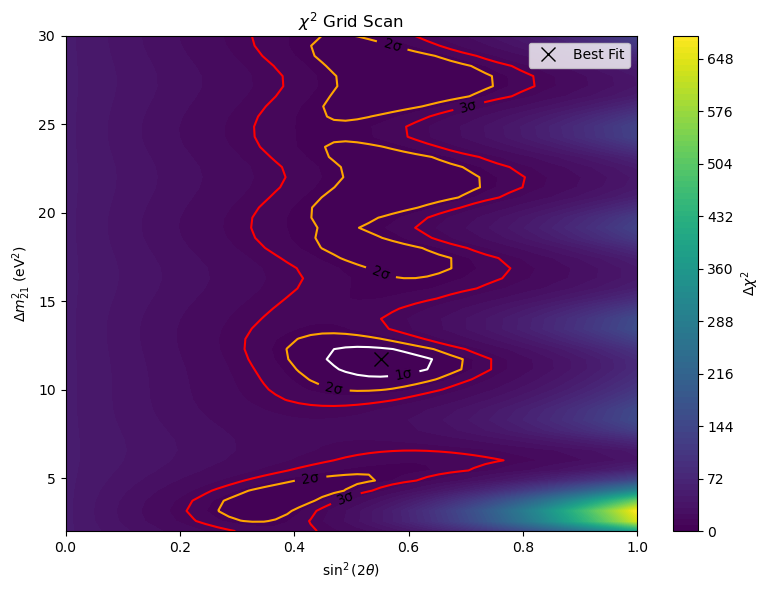

Minimum χ² = 0.039
Best sin²(2θ) = 0.5510
Best Δm² = 11.7143 eV²


In [22]:
# --- χ² minimum and best-fit point ---
chi_min = np.min(chi_mesh)
sine_mesh, delta_mesh = np.meshgrid(sine_list, delta_list, indexing = 'ij')
i_min, j_min = np.unravel_index(np.argmin(chi_mesh), chi_mesh.shape)
best_sine  = sine_list[i_min]
best_delta = delta_list[j_min]

# --- Plot Δχ² field (shift by min for proper confidence contours) ---
plt.figure(figsize=(8, 6))
delta_chi = chi_mesh - chi_min
contourf = plt.contourf(
    sine_mesh, delta_mesh, delta_chi,
    levels=100, cmap="viridis"
)
plt.colorbar(contourf, label=r"$\Delta\chi^2$")

# --- Confidence level contours for 2 parameters ---
levels_2d = [2.30, 6.18, 11.83]  # 1σ, 2σ, 3σ
lines = plt.contour(
    sine_mesh, delta_mesh, delta_chi,
    levels=levels_2d, colors=["white", "orange", "red"],
    linewidths=1.5
)
plt.clabel(lines, fmt={2.30:"1σ", 6.18:"2σ", 11.83:"3σ"},
           inline=True, fontsize=10, colors="black")

# --- Best-fit marker ---
plt.plot(best_sine, best_delta, "kx", markersize=10, label="Best Fit")

# --- Axes & labels ---
#plt.yscale("log")  # Δm^2 usually shown on a log scale
plt.xlabel(r"$\sin^2(2\theta)$")
plt.ylabel(r"$\Delta m^2_{21}$ (eV$^2$)")
plt.title(r"$\chi^2$ Grid Scan")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# --- Print best-fit values ---
print(f"Minimum χ² = {chi_min:.3f}")
print(f"Best sin²(2θ) = {best_sine:.4f}")
print(f"Best Δm² = {best_delta:.6g} eV²")


In [23]:
plt.figure()
contours = plt.contour(sine_mesh, delta_mesh, delta_chi,
    levels=levels_2d)
array = contours.allsegs[0][0]
sine_uncertainty = (np.max(array[:, 0]-np.min(array[:, 0])))/2
delta_uncertainty = (np.max(array[:, 1]-np.min(array[:, 1])))/2
plt.close()
sine_up = np.max(array[:, 0])-best_sine
sine_down = best_sine-np.min(array[:, 0])
delta_up = np.max(array[:, 1])-best_delta
delta_down = best_delta-np.min(array[:, 1])

print("==== 1σ Uncertainties from Contour ====")
print(f"Best-fit sin²(2θ) = {best_sine:.5f}")
print(f"    +{sine_up:.5f} / -{sine_down:.5f}  (asymmetric)")
print(f"    ±{sine_uncertainty:.5f}  (symmetric half-width)")
print()
print(f"Best-fit Δm²₍₂₁₎ = {best_delta:.5f} eV²")
print(f"    +{delta_up:.5f} / -{delta_down:.5f}  (asymmetric)")
print(f"    ±{delta_uncertainty:.5f}  (symmetric half-width)")
print("=======================================")


==== 1σ Uncertainties from Contour ====
Best-fit sin²(2θ) = 0.55102
    +0.09022 / -0.09426  (asymmetric)
    ±0.09224  (symmetric half-width)

Best-fit Δm²₍₂₁₎ = 11.71429 eV²
    +0.69943 / -0.98567  (asymmetric)
    ±0.84255  (symmetric half-width)


In [24]:

# Function that loops the above function across range of values of delM21 and sin^2(2theta)

In [25]:
# plot contourf function and find minimum!

Apply your above defined functions, and represent your result with matplotlib's contour and fcontour.

In [56]:
size = 500
sine_list =np.logspace(-3,0,size)
delta_list = np.logspace(-1,2,size)

chi_mesh = chi_grid_histloop_exact(
    MC_EXT_CUT, data_frame_cut,
    variable="trk_energy_tot",
    n_bins=37,
    rng=(0.0, 3.0),
    sine_list=sine_list,
    delta_list=delta_list,
    length=0.45,
    size=size)


8924
1848


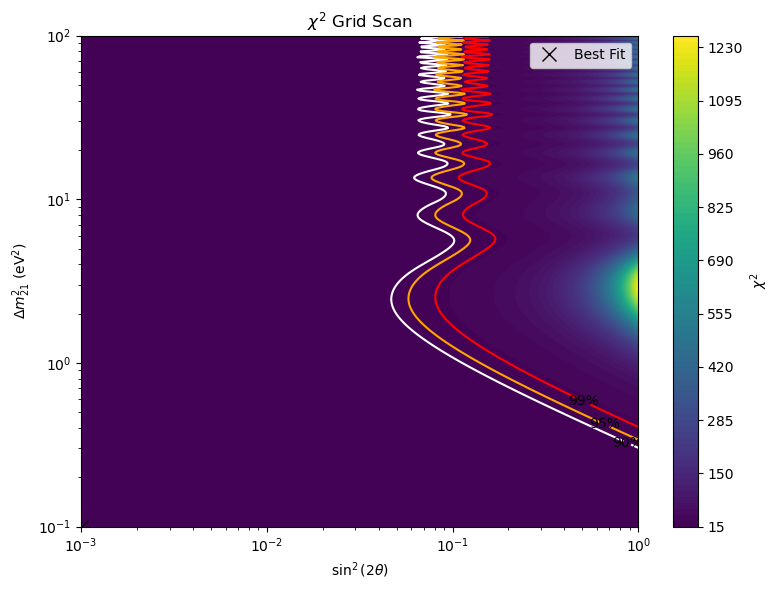

Minimum χ² = 18.317
Best sin²(2θ) = 0.0010
Best Δm² = 0.1 eV²


In [57]:
sine_mesh, delta_mesh = np.meshgrid(sine_list, delta_list, indexing = 'ij')
print(len(MC_EXT_OSC))
print(len(data_frame_cut))
# --- χ² minimum and best-fit point ---
chi_min = np.min(chi_mesh)
i_min, j_min = np.unravel_index(np.argmin(chi_mesh), chi_mesh.shape)
best_sine  = sine_list[i_min]
best_delta = delta_list[j_min]

# --- Plot Δχ² field (shift by min for proper confidence contours) ---
plt.figure(figsize=(8, 6))
delta_chi = chi_mesh - chi_min
contourf = plt.contourf(
    sine_mesh, delta_mesh, chi_mesh,
    levels=100, cmap="viridis"
)
plt.colorbar(contourf, label=r"$\chi^2$")

# --- Confidence level contours for 2 parameters ---
levels_2d = [4.61+chi_min, 5.99+chi_min, 9.21+chi_min]  # 1σ, 2σ, 3σ
lines = plt.contour(
    sine_mesh, delta_mesh, chi_mesh,
    levels=levels_2d, colors=["white", "orange", "red"],
    linewidths=1.5
)
plt.clabel(lines, fmt={4.61 + chi_min: "90%", 5.99 + chi_min: "95%", 9.21 + chi_min: "99%"},
           inline=True, fontsize=10, colors="black")

# --- Best-fit marker ---
plt.plot(best_sine, best_delta, "kx", markersize=10, label="Best Fit")

# --- Axes & labels ---
plt.yscale("log")  # Δm^2 usually shown on a log scale
plt.xscale("log") 
plt.xlabel(r"$\sin^2(2\theta)$")
plt.ylabel(r"$\Delta m^2_{21}$ (eV$^2$)")
plt.title(r"$\chi^2$ Grid Scan")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# --- Print best-fit values ---
print(f"Minimum χ² = {chi_min:.3f}")
print(f"Best sin²(2θ) = {best_sine:.4f}")
print(f"Best Δm² = {best_delta:.6g} eV²")

### Bonus: Minimise

Minimise your chi square value, determining the parameters of 'best fit'

### Confidence levels and parameter minima. 
Determine confidence levels, and find the parameter values that correspond to the lowest chi squared value within your range.with

In [58]:
# contour application, with correct confidence levels.

In [59]:
# find lowest chi squared value within range and plot with CL, or contourf plot.

# Exercise 13/14: 3+1 Framework Neutrino disappearance.

In [60]:
sine_mesh_scaled = (1 - (1 - sine_mesh)**0.5) * (1 - (1 - 0.24)**0.5)
sine_list_scaled = (1 - (1 - sine_list)**0.5) * (1 - (1 - 0.24)**0.5)

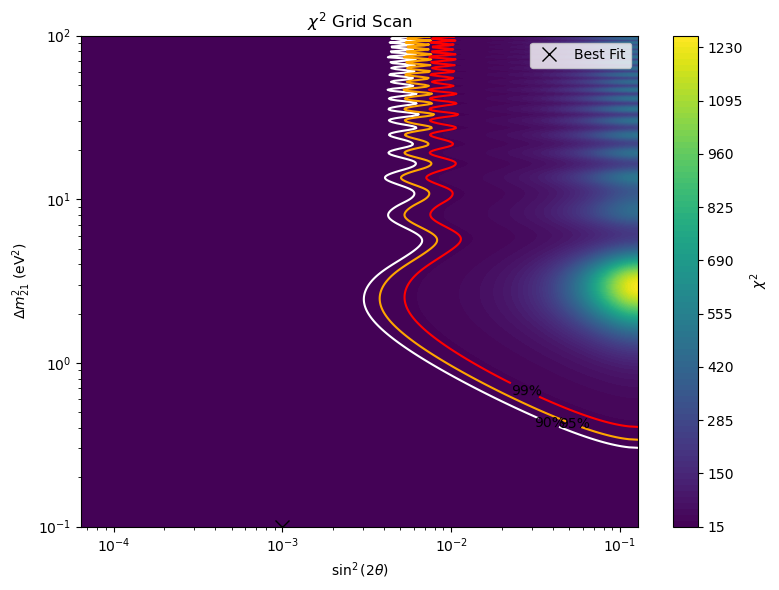

Minimum χ² = 18.317
Best sin²(2θ) = 0.0010
Best Δm² = 0.1 eV²
18.316953886630028


In [61]:
plt.figure(figsize=(8, 6))
contourf = plt.contourf(
    sine_mesh_scaled, delta_mesh, chi_mesh,
    levels=100, cmap="viridis"
)
plt.colorbar(contourf, label=r"$\chi^2$")

# --- Confidence level contours for 2 parameters ---
levels_2d = [4.61+chi_min, 5.99+chi_min, 9.21+chi_min]  # 1σ, 2σ, 3σ
lines = plt.contour(
    sine_mesh_scaled, delta_mesh, chi_mesh,
    levels=levels_2d, colors=["white", "orange", "red"],
    linewidths=1.5
)
plt.clabel(lines, fmt={4.61 + chi_min: "90%", 5.99 + chi_min: "95%", 9.21 + chi_min: "99%"},
           inline=True, fontsize=10, colors="black")

# --- Best-fit marker ---
plt.plot(best_sine, best_delta, "kx", markersize=10, label="Best Fit")

# --- Axes & labels ---
plt.yscale("log")  # Δm^2 usually shown on a log scale
plt.xscale("log") 
plt.xlabel(r"$\sin^2(2\theta)$")
plt.ylabel(r"$\Delta m^2_{21}$ (eV$^2$)")
plt.title(r"$\chi^2$ Grid Scan")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# --- Print best-fit values ---
print(f"Minimum χ² = {chi_min:.3f}")
print(f"Best sin²(2θ) = {best_sine:.4f}")
print(f"Best Δm² = {best_delta:.6g} eV²")
print(chi_min)

# Compare your result with MiniBooNE

Results are extracted from MiniBooNE (orange) and LSND (blue)

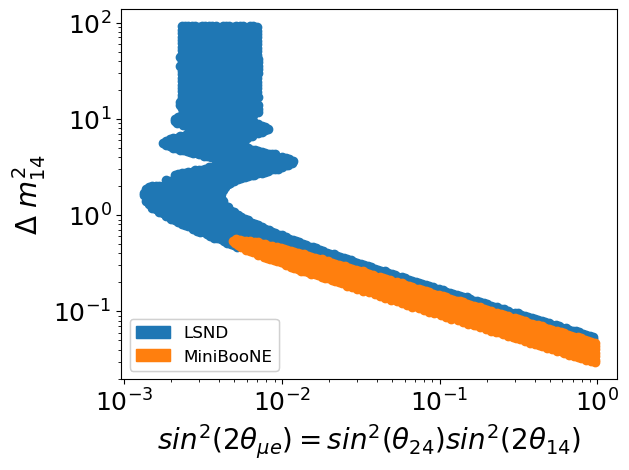

In [62]:
# Load data
LSND_data = pd.read_csv('./data/DataSet_LSND.csv').to_numpy()
MiniBooNE_data = pd.read_csv('./data/DataSet_MiniBooNE.csv').to_numpy()

# Plot data
plt.plot(LSND_data[:,0],LSND_data[:,1],'o')
plt.plot(MiniBooNE_data[:,0],MiniBooNE_data[:,1],'o')

# Producing MiniBooNE/LSND legend
LSND_path = mpatches.Patch(color='tab:blue', label = 'LSND')
MINI_path = mpatches.Patch(color='tab:orange', label = 'MiniBooNE')
first_legend = plt.legend(handles=[LSND_path, MINI_path], loc = 'lower left', fontsize = 12)
plt.gca().add_artist(first_legend)


plt.xlabel(r'$sin^2(2\theta_{\mu e})=sin^2(\theta_{24})sin^2(2\theta_{14})$',fontsize=20)
plt.ylabel(r'$\Delta$ $m_{14}^2$',fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.yscale('log')
plt.xscale('log')
plt.show()

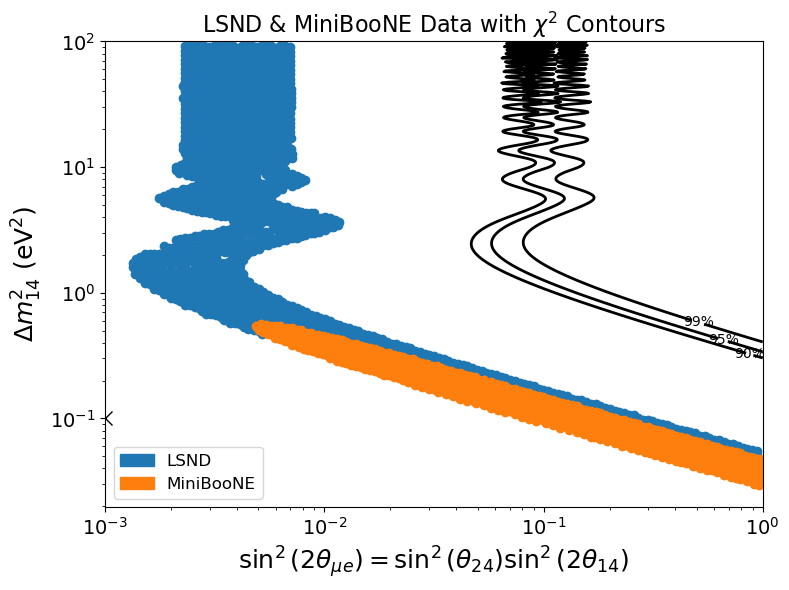

18.316953886630028


In [63]:
plt.figure(figsize=(8, 6))
plt.plot(LSND_data[:,0], LSND_data[:,1], 'o', color='tab:blue', label='LSND')
plt.plot(MiniBooNE_data[:,0], MiniBooNE_data[:,1], 'o', color='tab:orange', label='MiniBooNE')

# --- χ² contour levels (from your first plot) ---
levels_2d = [4.61 + chi_min, 5.99 + chi_min, 9.21 + chi_min]  # 1σ, 2σ, 3σ

# Add contour lines from your fit
lines = plt.contour(
    sine_mesh, delta_mesh, chi_mesh,
    levels=levels_2d,
    colors=["black", "black", "black"],
    linewidths=2
)

# Label the contours
plt.clabel(
    lines,
    fmt={4.61 + chi_min: "90%", 5.99 + chi_min: "95%", 9.21 + chi_min: "99%"},
    inline=True, fontsize=10, colors="black"
)

# --- Optional best-fit marker ---
plt.plot(best_sine, best_delta, "kx", markersize=10, label="Best Fit")

# --- Legend combining both datasets and contours ---
LSND_patch = mpatches.Patch(color='tab:blue', label='LSND')
MINI_patch = mpatches.Patch(color='tab:orange', label='MiniBooNE')
plt.legend(
    handles=[LSND_patch, MINI_patch],
    loc='lower left',
    fontsize=12
)

# --- Axes and labels ---
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\sin^2(2\theta_{\mu e}) = \sin^2(\theta_{24}) \sin^2(2\theta_{14})$', fontsize=18)
plt.ylabel(r'$\Delta m_{14}^2$ (eV$^2$)', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(r'LSND & MiniBooNE Data with $\chi^2$ Contours', fontsize=16)
plt.tight_layout()
plt.show()
print(chi_min)

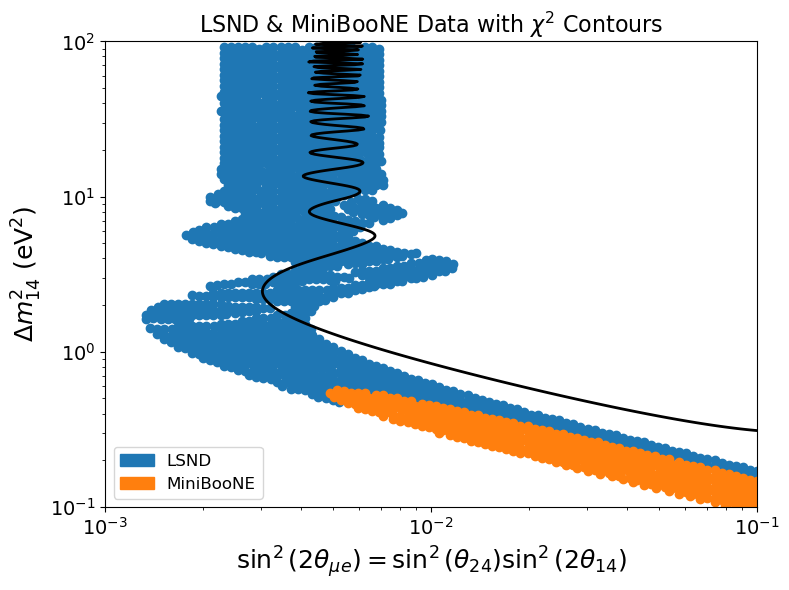

In [68]:
# --- Base scatter plot (data points) ---
plt.figure(figsize=(8, 6))
plt.plot(LSND_data[:,0], LSND_data[:,1], 'o', color='tab:blue', label='LSND')
plt.plot(MiniBooNE_data[:,0], MiniBooNE_data[:,1], 'o', color='tab:orange', label='MiniBooNE')

# --- χ² contour levels (from your first plot) ---
levels_2d = [4.61 + chi_min]  # 1σ, 2σ, 3σ

# Add contour lines from your fit
lines = plt.contour(
    sine_mesh_scaled, delta_mesh, chi_mesh,
    levels=levels_2d,
    colors=["black", "black", "black"],
    linewidths=2
)

# Label the contours
#plt.clabel(
    #lines,
    #fmt={4.61 + chi_min: "90%", 5.99 + chi_min: "95%", 9.21 + chi_min: "99%"},
    #inline=True, fontsize=10, colors="black"
#)

# --- Optional best-fit marker ---
#plt.plot(best_sine, best_delta, "kx", markersize=10, label="Best Fit")

# --- Legend combining both datasets and contours ---
LSND_patch = mpatches.Patch(color='tab:blue', label='LSND')
MINI_patch = mpatches.Patch(color='tab:orange', label='MiniBooNE')
plt.legend(
    handles=[LSND_patch, MINI_patch],
    loc='lower left',
    fontsize=12
)

# --- Axes and labels ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-3, 1e-1)   # example range
plt.ylim(1e-1, 1e2) 
#plt.ylim(1e-1, 1e2)   # if you also want to limit y-range
plt.xlabel(r'$\sin^2(2\theta_{\mu e}) = \sin^2(\theta_{24}) \sin^2(2\theta_{14})$', fontsize=18)
plt.ylabel(r'$\Delta m_{14}^2$ (eV$^2$)', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(r'LSND & MiniBooNE Data with $\chi^2$ Contours', fontsize=16)
plt.tight_layout()
plt.show()

MC_EXT_CUT:    bins=26,    M=3.000, bin_width=0.0702145
data_frame_cut: bins=20, M=2.650, bin_width=0.0866405


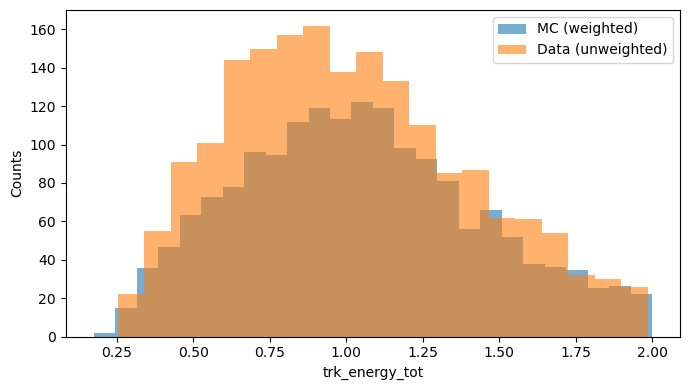

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _nn_gaps_from_unique(xu: np.ndarray) -> np.ndarray:
    """
    Given strictly increasing unique samples xu (size m>=2),
    return r of size m where:
      r[1:-1] = min(xu[i]-xu[i-1], xu[i+1]-xu[i])
      r[0]    = xu[1]-xu[0]
      r[-1]   = xu[-1]-xu[-2]
    """
    m = xu.size
    left = xu[1:] - xu[:-1]              # size m-1
    r = np.empty(m, dtype=np.float64)    # size m
    r[1:-1] = np.minimum(left[:-1], left[1:])
    r[0]    = left[0]
    r[-1]   = left[-1]
    return r

def optimal_bins_shannon(df, variable, weights_col=None, M_default=2.0, search_M=True):
    # pull column and mask finite
    x_all = df[variable].to_numpy(dtype=float)
    finite = np.isfinite(x_all)
    x = x_all[finite]
    if x.size < 2:
        raise ValueError("Not enough valid data points")

    # weights aligned with the same mask (or ones if absent)
    if weights_col and (weights_col in df):
        w_all = df[weights_col].to_numpy(dtype=float)
        w = w_all[finite]
        w[~np.isfinite(w)] = 0.0
    else:
        w = np.ones_like(x)

    # --- 1D KL entropy (nats), robust to ties via unique samples ---
    xu = np.unique(x)
    if xu.size < 2:
        raise ValueError("All values are identical")
    r = _nn_gaps_from_unique(xu)
    # harmonic number H_{N-1}
    Hn1 = np.sum(1.0 / np.arange(1, xu.size, dtype=np.float64))
    h_nats = Hn1 + np.log(2.0) + np.mean(np.log(r))

    N = x.size
    lo, hi = float(np.min(x)), float(np.max(x))
    if lo == hi:
        hi = lo + 1.0
    pad = 1e-12 * (hi - lo)
    lo, hi = lo, hi + pad

    def bins_from_M(M: float):
        delta = np.exp(h_nats) * N ** (-1.0 / M)      # Δ = e^h N^{-1/M}
        span = hi - lo
        bins = int(np.ceil(span / max(delta, 1e-300)))
        bins = max(bins, 1)
        edges = np.linspace(lo, hi, bins + 1)
        delta_eff = span / bins
        return bins, delta_eff, edges

    def ss_cost(counts: np.ndarray, delta: float):
        m = np.mean(counts); v = np.var(counts)
        return (2.0 * m - v) / (delta * delta + 1e-300)

    def cost_for_M(M: float):
        bins, delta, edges = bins_from_M(M)
        hist, _ = np.histogram(x, bins=edges, weights=w)
        return ss_cost(hist.astype(float), delta), (bins, delta, edges)

    if search_M:
        best = None
        for M in np.linspace(2.0, 3.0, 21):
            c, vals = cost_for_M(M)
            if (best is None) or (c < best[0]):
                best = (c, M, *vals)
        _, M_opt, bins, delta, edges = best
    else:
        bins, delta, edges = bins_from_M(M_default)
        M_opt = float(M_default)

    return {"bins": int(bins), "edges": edges, "bin_width": float(delta), "M": M_opt}

# ---- separate runs (unchanged) ----
res_mc   = optimal_bins_shannon(MC_EXT_CUT,    variable="trk_energy_tot", weights_col="weight", search_M=True)
res_data = optimal_bins_shannon(data_frame_cut, variable="trk_energy_tot", weights_col=None,    search_M=True)

print(f"MC_EXT_CUT:    bins={res_mc['bins']},    M={res_mc['M']:.3f}, bin_width={res_mc['bin_width']:.6g}")
print(f"data_frame_cut: bins={res_data['bins']}, M={res_data['M']:.3f}, bin_width={res_data['bin_width']:.6g}")

# quick visual
plt.figure(figsize=(7,4))
plt.hist(MC_EXT_CUT["trk_energy_tot"], bins=res_mc["edges"], weights=MC_EXT_CUT.get("weight"), alpha=0.6, label="MC (weighted)")
plt.hist(data_frame_cut["trk_energy_tot"], bins=res_data["edges"], alpha=0.6, label="Data (unweighted)")
plt.xlabel("trk_energy_tot"); plt.ylabel("Counts"); plt.legend(); plt.tight_layout(); plt.show()
